## Generating distributions

Shape of the samples: torch.Size([10000, 2]) torch.Size([10000, 2])


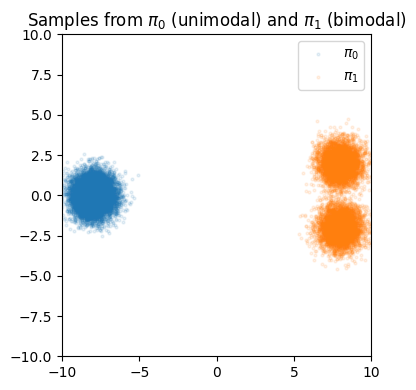

In [4]:
import torch
import numpy as np
import torch.nn as nn
from torch.distributions import Normal
from torch.distributions.multivariate_normal import MultivariateNormal
from torch.distributions.mixture_same_family import MixtureSameFamily
from torch.distributions import Categorical
import matplotlib.pyplot as plt

OFFSET = 8.0   # translation along x-axis
VAR = 0.5
M = 10
DOT_SIZE = 4

# Initial: unimodal Gaussian centered at (-OFFSET, 0)
initial_model = MultivariateNormal(
    torch.tensor([-OFFSET, 0.0]),
    VAR * torch.eye(2)
)
samples_0 = initial_model.sample([10000])

# Target: bimodal Gaussian centered at (+OFFSET ± gap, ±2)
target_mix = Categorical(torch.tensor([0.5, 0.5]))
target_comp = MultivariateNormal(
    torch.tensor([[OFFSET, -2.0], [OFFSET, 2.0]]),
    VAR * torch.stack([torch.eye(2), torch.eye(2)])
)
target_model = MixtureSameFamily(target_mix, target_comp)
samples_1 = target_model.sample([10000])

print('Shape of the samples:', samples_0.shape, samples_1.shape)

plt.figure(figsize=(4, 4))
plt.xlim(-M, M)
plt.ylim(-M, M)
plt.title(r'Samples from $\pi_0$ (unimodal) and $\pi_1$ (bimodal)')
plt.scatter(samples_0[:, 0].cpu().numpy(), samples_0[:, 1].cpu().numpy(), alpha=0.1, s=DOT_SIZE, label=r'$\pi_0$')
plt.scatter(samples_1[:, 0].cpu().numpy(), samples_1[:, 1].cpu().numpy(), alpha=0.1, s=DOT_SIZE, label=r'$\pi_1$')
plt.legend()
plt.tight_layout()
plt.show()